In [1]:
# import pandas --- spreadsheet library
import pandas as pd

import numpy as np

# import matplotlib --- plotting library
import matplotlib.pyplot as plt

from plotting import make_overview, compare
from myio import read_in_weather_data

In [2]:
%matplotlib inline

In [3]:
import os

fdir = '../../Data/Calibration Data/Sinarmas/Clean data'

fpath = os.path.join(fdir,'Yield/Mwhe-1986.csv')
dfo = pd.read_csv(fpath)
dfo = dfo.set_index(pd.to_datetime(dfo['Month']))
dfo = dfo.dropna(how='all')

fpath = os.path.join(fdir, 'Weather/MWHE.csv')
dfw = read_in_weather_data(fpath)

In [4]:
dfo = dfo.dropna(how='all')

In [5]:
import sys
sys.path.append('../PalmSim')
sys.path.append('..')
from palmsim import PalmField

from palmsim import Indeterminate

# different variety!
Indeterminate.parameters['potential_mass_a']['value'] = 19

# 1. Initialize the model
dt = 10

p = PalmField(year_of_planting=1993, month_of_planting=1, dt=dt)
p.soil.parameters['water_holding_capacity']['value'] = 500

# 2. Couple the solar radiation data:
dfw = dfw.resample('D').pad()
dfw = dfw.rolling(dt, center=True).mean()
dfw = dfw.fillna(method='pad')

p.weather.radiation_series = dfw['Solar']
p.weather.rainfall_series = dfw['Precip']
p.weather.humidity_series = dfw['RelHum']

nyears = 30

duration = nyears*365

df = p.run(duration=duration)

Saving at: plots\MWHE.png


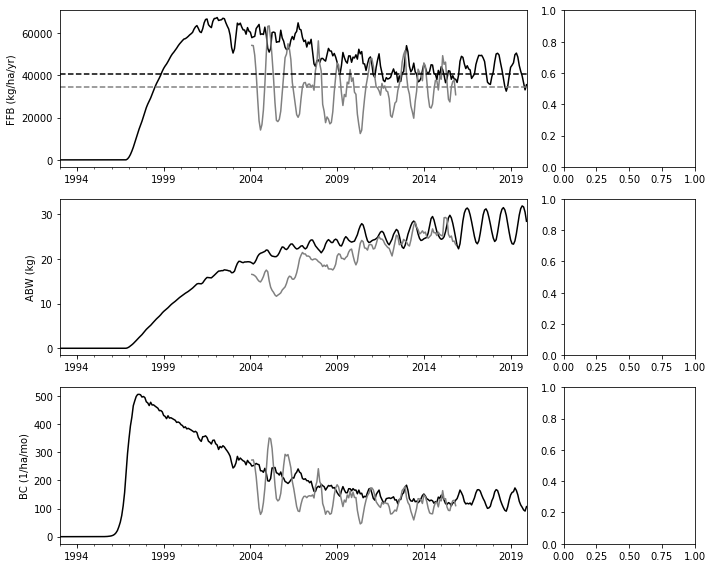

In [6]:
sname = 'MWHE'

make_overview(df, dfo, sname, window=3)

Saving at: plots\MWHE.png


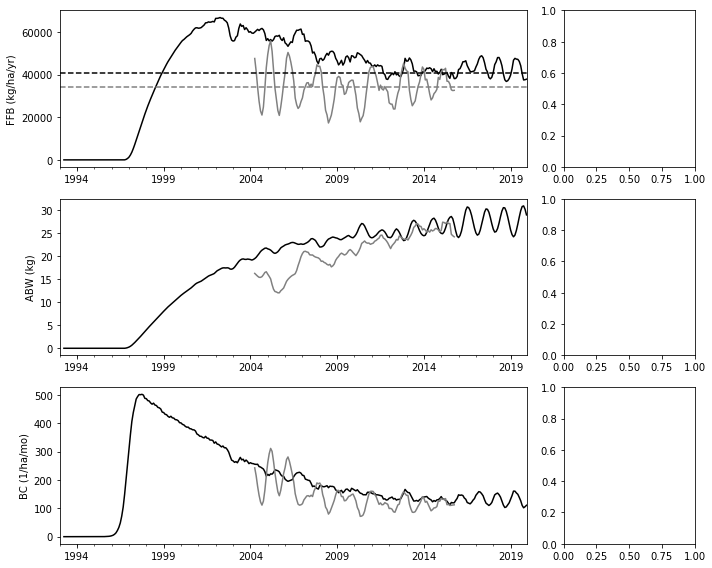

In [7]:
make_overview(df, dfo, sname, window=6)

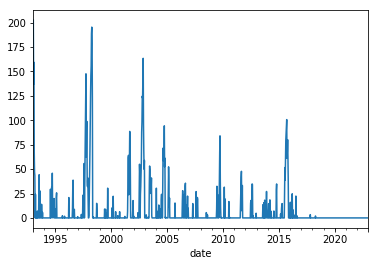

In [8]:
df['soil_water_deficit (mm)'].plot()

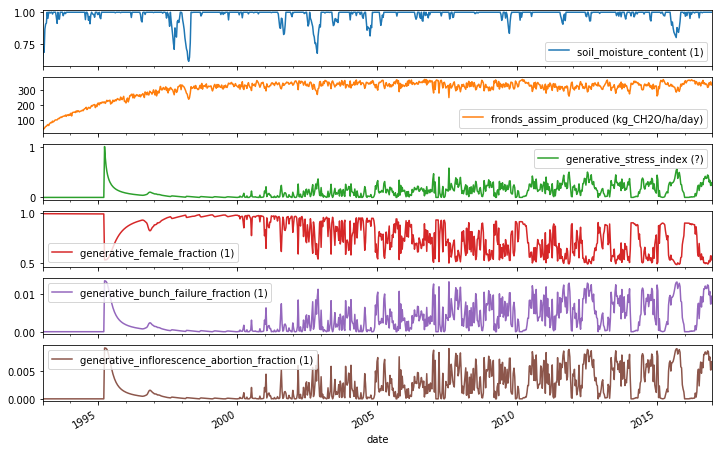

In [9]:
cs = ['soil_moisture_content (1)',
      'fronds_assim_produced (kg_CH2O/ha/day)',
      'generative_stress_index (?)',
      'generative_female_fraction (1)',
      'generative_bunch_failure_fraction (1)',
     'generative_inflorescence_abortion_fraction (1)']

df.loc['1993':'2016',cs].plot(subplots=True, figsize=(12,8));

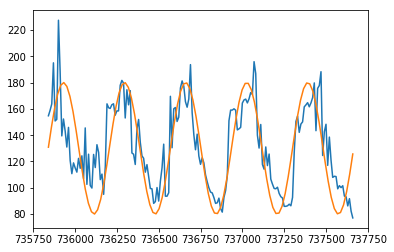

In [10]:
xs = df.loc['2016':'2020'].index.dayofyear.values + 365*df.loc['2016':'2020'].index.year.values
ys = df.loc['2016':'2020','generative_bunch_count (1/ha/mo)'].values

f = lambda t, offset, amplitude, period, t0: offset + amplitude*np.sin(2*np.pi*(t - t0)/period)

plt.plot(xs, ys)

xsm = np.linspace(xs[0],xs[-1],100)

plt.plot(xsm, f(xsm, 130, 50, 365, 0))

In [11]:
c = 1/365
(c*df['generative_t_maturity (?)']).head()

date
1993-01-11    2.159297
1993-01-21    2.160423
1993-01-31    2.161553
1993-02-10    2.162688
1993-02-20    2.163827
Freq: 10D, Name: generative_t_maturity (?), dtype: float64

In [12]:
(c*df['generative_t_maturity (?)']).tail()

date
2022-11-15    3.796217
2022-11-25    3.796422
2022-12-05    3.796626
2022-12-15    3.796828
2022-12-25    3.797030
Freq: 10D, Name: generative_t_maturity (?), dtype: float64

In [13]:
(c*0.8*df['generative_t_maturity (?)']).head()

date
1993-01-11    1.727437
1993-01-21    1.728338
1993-01-31    1.729242
1993-02-10    1.730150
1993-02-20    1.731061
Freq: 10D, Name: generative_t_maturity (?), dtype: float64

In [14]:
(c*0.8*df['generative_t_maturity (?)']).tail()

date
2022-11-15    3.036973
2022-11-25    3.037137
2022-12-05    3.037300
2022-12-15    3.037463
2022-12-25    3.037624
Freq: 10D, Name: generative_t_maturity (?), dtype: float64

In [15]:
c*0.25*(df['generative_t_maturity (?)'].head())

date
1993-01-11    0.539824
1993-01-21    0.540106
1993-01-31    0.540388
1993-02-10    0.540672
1993-02-20    0.540957
Freq: 10D, Name: generative_t_maturity (?), dtype: float64

In [16]:
c*0.25*(df['generative_t_maturity (?)'].tail())

date
2022-11-15    0.949054
2022-11-25    0.949105
2022-12-05    0.949156
2022-12-15    0.949207
2022-12-25    0.949258
Freq: 10D, Name: generative_t_maturity (?), dtype: float64